# PaddleOCR Photo OCR Notebook

Run cells top-to-bottom. This notebook installs dependencies into the **current kernel Python** and then runs OCR on a photo.

In [1]:
import sys
import platform
import subprocess

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"Machine: {platform.machine()}")

def run(cmd):
    print("+", " ".join(cmd))
    subprocess.run(cmd, check=True)

run([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
run([sys.executable, "-m", "pip", "install", "pillow", "matplotlib", "pandas", "paddleocr"])

# Install a stable Paddle runtime compatible with PaddleOCR 3.x
PADDLE_VERSION = "3.1.1"
cmd = [sys.executable, "-m", "pip", "install", f"paddlepaddle=={PADDLE_VERSION}"]
standard = subprocess.run(cmd, check=False)

# macOS arm64 fallback from official Paddle index
if standard.returncode != 0 and platform.system() == "Darwin" and platform.machine() == "arm64":
    fallback = subprocess.run([
        sys.executable, "-m", "pip", "install",
        "-i", "https://www.paddlepaddle.org.cn/packages/stable/cpu/",
        f"paddlepaddle=={PADDLE_VERSION}"
    ], check=False)
    if fallback.returncode != 0:
        raise RuntimeError(
            f"Failed to install paddlepaddle=={PADDLE_VERSION} for this kernel. "
            "Run the printed commands manually in terminal, then restart kernel."
        )
elif standard.returncode != 0:
    raise RuntimeError(f"Failed to install paddlepaddle=={PADDLE_VERSION}.")

print("Install complete. Restart kernel once, then continue.")

Python executable: /Users/leonardmirt/projects/DocExtract/doc_extract/bin/python
Python version: 3.9.6
Platform: macOS-26.3-arm64-arm-64bit
Machine: arm64
+ /Users/leonardmirt/projects/DocExtract/doc_extract/bin/python -m pip install --upgrade pip
  Attempting uninstall: pip
    Found existing installation: pip 21.2.4
    Uninstalling pip-21.2.4:
      Successfully uninstalled pip-21.2.4
+ /Users/leonardmirt/projects/DocExtract/doc_extract/bin/python -m pip install pillow matplotlib pandas paddleocr
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━ 80.7/98.0 MB 6.3 MB/s eta 0:00:03


Resuming download paddlepaddle-3.1.1-cp39-cp39-macosx_11_0_arm64.whl (80.7 MB/98.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.0/98.0 MB 3.9 MB/s  0:00:04m0:00:0100:010m
  Attempting uninstall: paddlepaddle
    Found existing installation: paddlepaddle 3.0.0b1
    Uninstalling paddlepaddle-3.0.0b1:
      Successfully uninstalled paddlepaddle-3.0.0b1
Install complete. Restart kernel once, then continue.


Paddle version: 3.1.1


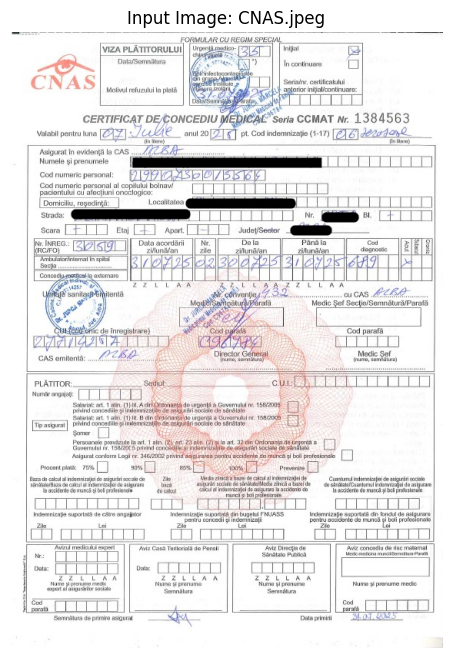

In [6]:
import sys
from pathlib import Path

try:
    import paddle
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "`paddle` is still missing in this kernel.\n"
        f"Kernel python: {sys.executable}\n"
        "Re-run install cell, then restart kernel and run from top."
    ) from exc

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from paddleocr import PaddleOCR

print(f"Paddle version: {paddle.__version__}")

# Set your image path here
IMAGE_PATH = Path.home() / "Desktop/CNAS.jpeg"
LANG = "en"

img_path = Path(IMAGE_PATH)
if not img_path.exists():
    raise FileNotFoundError(f"Image not found: {img_path}")

img = Image.open(img_path).convert("RGB")
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.title(f"Input Image: {img_path.name}")
plt.show()

In [17]:
# Initialize OCR engine and run inference
ocr = PaddleOCR(use_angle_cls=True, lang=LANG)
result = ocr.predict(str(img_path))

# Normalize output format
raw_lines = result[0] if result and isinstance(result, list) and len(result) > 0 else []
rows = []
print(raw_lines)
for item in raw_lines:
    if not item or len(item) < 2:
        continue
    box = item[0]
    text = item[1][0]
    score = 0.0
    if (len(item[1]) > 1):
        score = float(item[1][1])
    rows.append({"text": text, "score": score, "box": box})

df = pd.DataFrame(rows)
if df.empty:
    print("No text detected.")
else:
    display(df[["text", "score"]].sort_values("score", ascending=False).reset_index(drop=True))

/var/folders/xl/w9n9mcjn6f56ksnq7c20h_p80000gn/T/ipykernel_10301/3708646940.py:2: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang=LANG)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/leonardmirt/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/leonardmirt/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/leonardmirt/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached fi

{'input_path': '/Users/leonardmirt/Desktop/CNAS.jpeg', 'page_index': None, 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'input_img': array([[[253, ..., 250],
        ...,
        [ 39, ...,  39]],

       ...,

       [[255, ..., 255],
        ...,
        [218, ..., 221]]], dtype=uint8), 'model_settings': {'use_doc_orientation_classify': True, 'use_doc_unwarping': True}, 'angle': 0, 'rot_img': array([[[253, ..., 250],
        ...,
        [ 39, ...,  39]],

       ...,

       [[255, ..., 255],
        ...,
        [218, ..., 221]]], dtype=uint8), 'output_img': array([[[255, ..., 255],
        ...,
        [255, ..., 255]],

       ...,

       [[254, ..., 254],
        ...,
        [255, ..., 255]]], dtype=uint8)}, 'dt_polys': [array([[11, 17],
       ...,
       [ 9, 49]], dtype=int16), array([[133,   8],
       ...,
       [133,  22]], dtype=int16), array([[357,  15],
       ...,
       [356,  29]], dtype=int16), array([[117,  46],
       ...,
       [116,  59]]

,text,score
0,n,0.0
1,a,0.0
2,o,0.0
3,t,0.0
4,o,0.0
5,e,0.0
6,e,0.0
7,e,0.0
8,e,0.0
9,e,0.0


In [ ]:
# Draw OCR boxes on the image
overlay = img.copy()
draw = ImageDraw.Draw(overlay)

for _, r in df.iterrows():
    pts = [tuple(map(float, p)) for p in r['box']]
    draw.polygon(pts, outline="red", width=2)

plt.figure(figsize=(12, 10))
plt.imshow(overlay)
plt.axis("off")
plt.title("Detected Text Regions")
plt.show()

if not df.empty:
    full_text = "\n".join(df["text"].tolist())
    print(full_text)

ValueError: could not convert string to float: 'i'

In [25]:
for i in raw_lines:
    print(i)
    print(raw_lines[i])
    print()

input_path
/Users/leonardmirt/Desktop/CNAS.jpeg

page_index
None

doc_preprocessor_res
{'input_path': None, 'page_index': None, 'input_img': array([[[253, ..., 250],
        ...,
        [ 39, ...,  39]],

       ...,

       [[255, ..., 255],
        ...,
        [218, ..., 221]]], dtype=uint8), 'model_settings': {'use_doc_orientation_classify': True, 'use_doc_unwarping': True}, 'angle': 0, 'rot_img': array([[[253, ..., 250],
        ...,
        [ 39, ...,  39]],

       ...,

       [[255, ..., 255],
        ...,
        [218, ..., 221]]], dtype=uint8), 'output_img': array([[[255, ..., 255],
        ...,
        [255, ..., 255]],

       ...,

       [[254, ..., 254],
        ...,
        [255, ..., 255]]], dtype=uint8)}

dt_polys
[array([[11, 17],
       ...,
       [ 9, 49]], dtype=int16), array([[133,   8],
       ...,
       [133,  22]], dtype=int16), array([[357,  15],
       ...,
       [356,  29]], dtype=int16), array([[117,  46],
       ...,
       [116,  59]], dtype=int16),

In [28]:
for i in range(len(raw_lines['rec_scores'])):
    print(raw_lines['rec_scores'][i])
    print(raw_lines['rec_texts'][i])
    print()

0.995952844619751
CNAS

0.8957124352455139
Data/Somnaitura

0.9856979846954346
In continuaro

0.924742579460144
Molivul refuzului la plata

0.9284057021141052
antorior initjial/continuare:

0.9792808890342712
Seria/nr. certificatului

0.8988620042800903
Dala/Samn

0.796038806438446
Valabil pentru lunaOuhe

0.902888298034668
anul 20pt. Cod indemnizatie (1-17)2

0.8931282758712769
Asigurat in evidenta la CAS.

0.8103713989257812
(in lora)

0.7379244565963745
(in lkeme)

0.9923767447471619
Numele si prenumele

0.9937662482261658
Cod numeric personal:

0.688835620880127
2199197360/35161

0.9917037487030029
Cod numeric personal al copilului bolnav/

0.9623696208000183
pacientului cu afectiuni oncclogice:

0.967034101486206
Domiciliu, resedinta:

0.9818879961967468
Localitatea

0.9972022771835327
Strada:

0.9996048808097839
Nr.

0.9316561222076416
BI.

0.9998792409896851
Scara

0.6885812878608704
+

0.999382495880127
Etaj

0.2574586868286133
±

0.9988773465156555
Apart.

0.9505054354667664
J